In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [6]:
df = pd.read_csv(r'd:\FCI\06-FCDS\DS_Tools\01_Assignments\WebScraping\All_products2.csv')

In [7]:
df.head()

,Product Name,Price,Rating,Best Seller,Brand,Discount,Department,website
0,Decathlon Men's Running Shoes Jogflow 100.1 Bl...,"EGP 1,799.00",4.4,0.0,Decathlon,0%,Shose,Jumia
1,Decathlon Men's Running Shoes Jogflow 100.1 Bl...,"EGP 1,799.00",4.6,0.0,Decathlon,0%,Shose,Jumia
2,Decathlon Agility 100 HG Adult Firm Pitch Foot...,"EGP 1,799.00",4.2,0.0,Decathlon,0%,Shose,Jumia
3,Decathlon RUN ACTIVE GRIP MEN'S RUNNING SHOES ...,"EGP 2,899.00",4.2,0.0,Decathlon,0%,Shose,Jumia
4,Decathlon Run Active Men's Running Shoes - Khaki,"EGP 2,899.00",4.4,0.0,Decathlon,0%,Shose,Jumia


# Cleaning the data

In [8]:
def clean_price(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, float)):
        return value 
    match = re.search(r'\d+(\.\d+)?', str(value).replace(',', ''))
    return float(match.group()) if match else None


In [9]:
df['Price'] = df['Price'].apply(clean_price)

df['Discount'] = df['Discount'].apply(lambda x: float(re.sub(r'[^\d.]', '', str(x))) if pd.notna(x) else 0.0)

df['Rating'] = df['Rating'].astype(float)
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())
print(df.dropna(inplace=True))

0
None


In [10]:
df.isnull().sum()

Product Name    0
Price           0
Rating          0
Best Seller     0
Brand           0
Discount        0
Department      0
website         0
dtype: int64

In [11]:
df["Price_After_Discount"] = df["Price"] * (1 - df["Discount"] / 100)


In [12]:
df_sample = df[["Product Name", "Price", "Price_After_Discount"]].head(10)


In [13]:
df.head(20)


,Product Name,Price,Rating,Best Seller,Brand,Discount,Department,website,Price_After_Discount
0,Decathlon Men's Running Shoes Jogflow 100.1 Bl...,1799.0,4.4,0.0,Decathlon,0.0,Shose,Jumia,1799.00
1,Decathlon Men's Running Shoes Jogflow 100.1 Bl...,1799.0,4.6,0.0,Decathlon,0.0,Shose,Jumia,1799.00
2,Decathlon Agility 100 HG Adult Firm Pitch Foot...,1799.0,4.2,0.0,Decathlon,0.0,Shose,Jumia,1799.00
3,Decathlon RUN ACTIVE GRIP MEN'S RUNNING SHOES ...,2899.0,4.2,0.0,Decathlon,0.0,Shose,Jumia,2899.00
4,Decathlon Run Active Men's Running Shoes - Khaki,2899.0,4.4,0.0,Decathlon,0.0,Shose,Jumia,2899.00
5,Decathlon JOGFLOW 500.1 Men's Running Shoes-White,3599.0,5.0,0.0,Decathlon,0.0,Shose,Jumia,3599.00
6,ADIDAS Advantage Base 2.0 Shoes - white,3458.0,4.4,0.0,ADIDAS,25.0,Shose,Jumia,2593.50
7,ADIDAS LIT48 Advantage Base Tennis Shoes - Ftw...,2450.0,4.7,0.0,ADIDAS,47.0,Shose,Jumia,1298.50
8,Decathlon Men's Waterproof Mountain Walking Sh...,5499.0,0.0,0.0,Decathlon,0.0,Shose,Jumia,5499.00
9,ADIDAS IF1402 Deportivo III Flexible Ground Boots,1927.0,4.2,0.0,ADIDAS,29.0,Shose,Jumia,1368.17


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1837 entries, 0 to 2063
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product Name          1837 non-null   object 
 1   Price                 1837 non-null   float64
 2   Rating                1837 non-null   float64
 3   Best Seller           1837 non-null   object 
 4   Brand                 1837 non-null   object 
 5   Discount              1837 non-null   float64
 6   Department            1837 non-null   object 
 7   website               1837 non-null   object 
 8   Price_After_Discount  1837 non-null   float64
dtypes: float64(4), object(5)
memory usage: 143.5+ KB


In [15]:
df.shape

(1837, 9)

In [66]:
print("Number of products:", len(df))
print("Minimum price     :", df["Price"].min())
print("Maximum price     :", df["Price"].max())
print("Average price     :", df["Price"].mean())
print("Minimum rate      :", df["Rating"].min())
print("Maximum rate      :", df["Rating"].max())
print("Average rate      :", df["Rating"].mean())
print("Number of brands  :", df["Brand"].nunique())
print("Maximum department:", df["Department"].mode()[0])
print("Percentage of products with discount:", (df["Discount"] > 0).mean() * 100, "%")


Number of products: 1837
Minimum price     : 9.99
Maximum price     : 219499.0
Average price     : 8094.088954817637
Minimum rate      : 0.0
Maximum rate      : 5.0
Average rate      : 2.4377245508982037
Number of brands  : 306
Maximum department: Clothes
Percentage of products with discount: 67.99129014697877 %


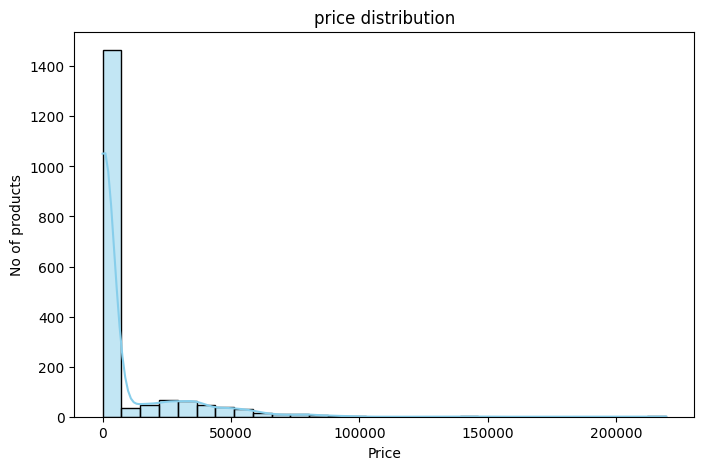

In [16]:

plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=30, kde=True, color="skyblue")
plt.title("price distribution")
plt.xlabel("Price")
plt.ylabel("No of products")
plt.show()


C:\Users\SH\AppData\Local\Temp\ipykernel_23332\2260030263.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette="viridis")


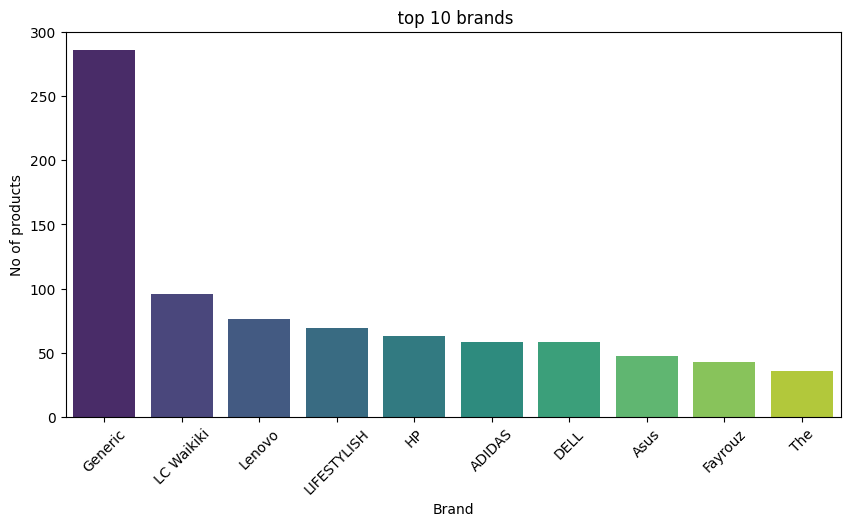

In [17]:
top_brands = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.index, y=top_brands.values, palette="viridis")
plt.title("  top 10 brands ")
plt.xlabel("Brand")
plt.ylabel("No of products")
plt.xticks(rotation=45)
plt.show()


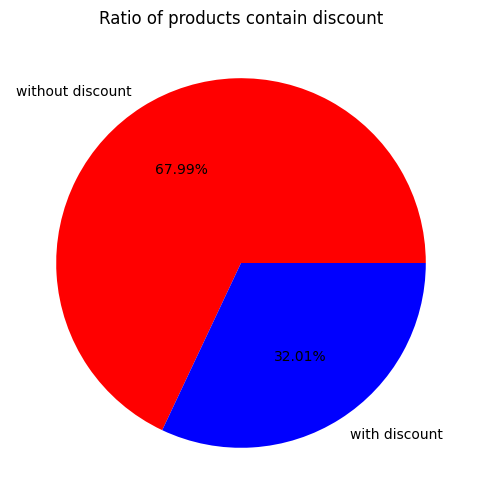

In [18]:
has_discount = (df["Discount"] > 0).sum()
no_discount = (df["Discount"] == 0).sum()

plt.figure(figsize=(6, 6))
plt.pie([has_discount, no_discount], labels=["without discount","with discount"], autopct='%1.2f%%', colors=["r", "b"])
plt.title("Ratio of products contain discount")
plt.show()


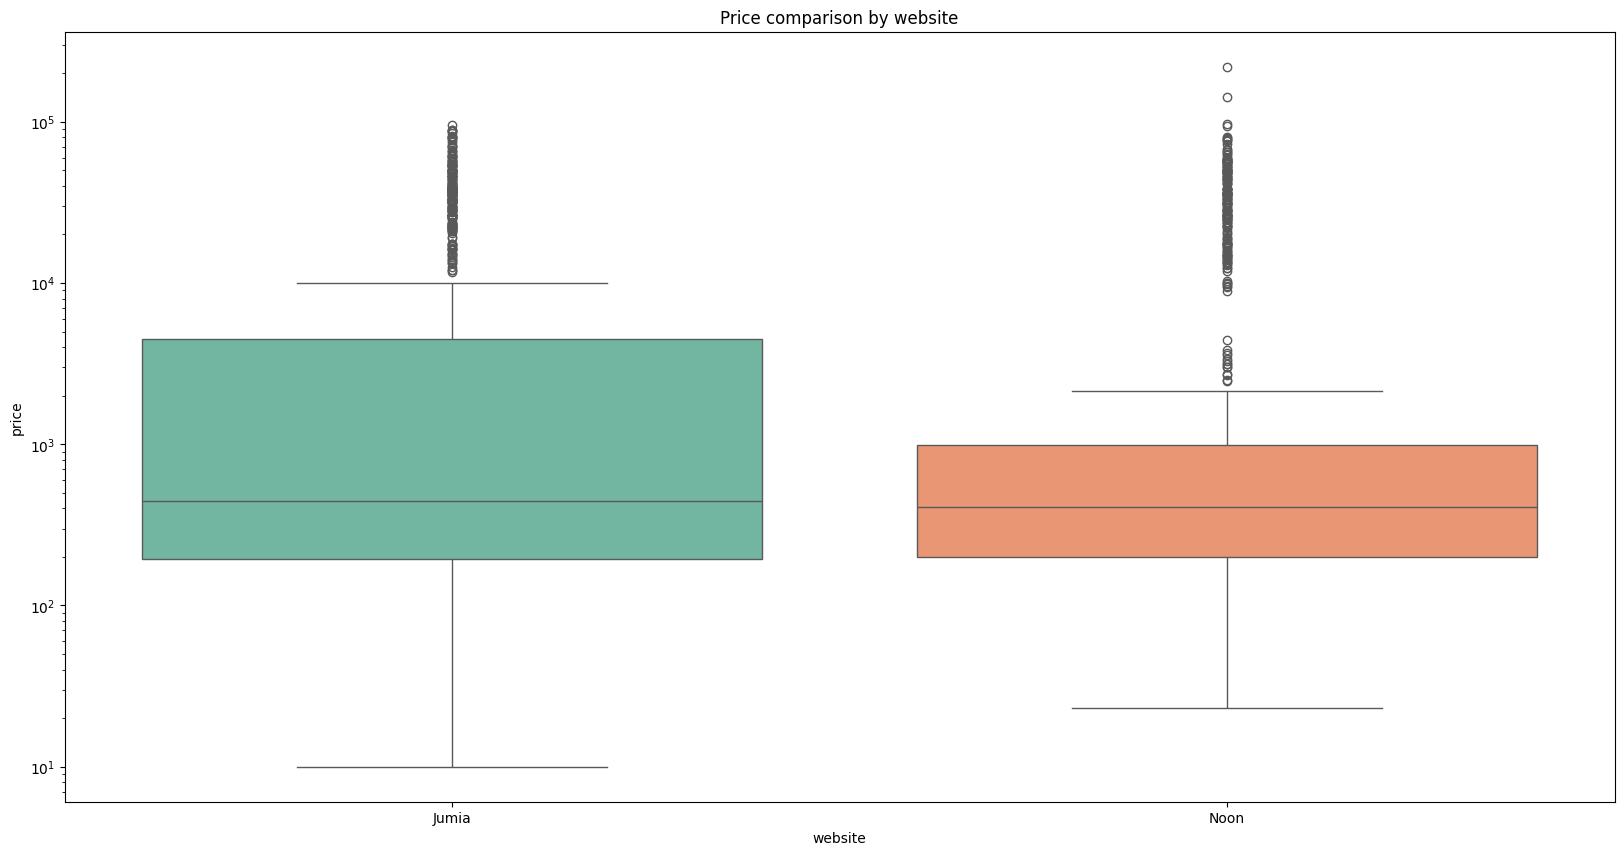

In [70]:
plt.figure(figsize=(20, 10))
#sns.boxplot(data=df, x="website", y="Price", palette="Set2")
sns.boxplot(data=df, x="website", y="Price", hue="website", palette="Set2", legend=False)
plt.yscale("log")  
plt.title("Price comparison by website")
plt.xlabel("website")
plt.ylabel("price")
plt.show()


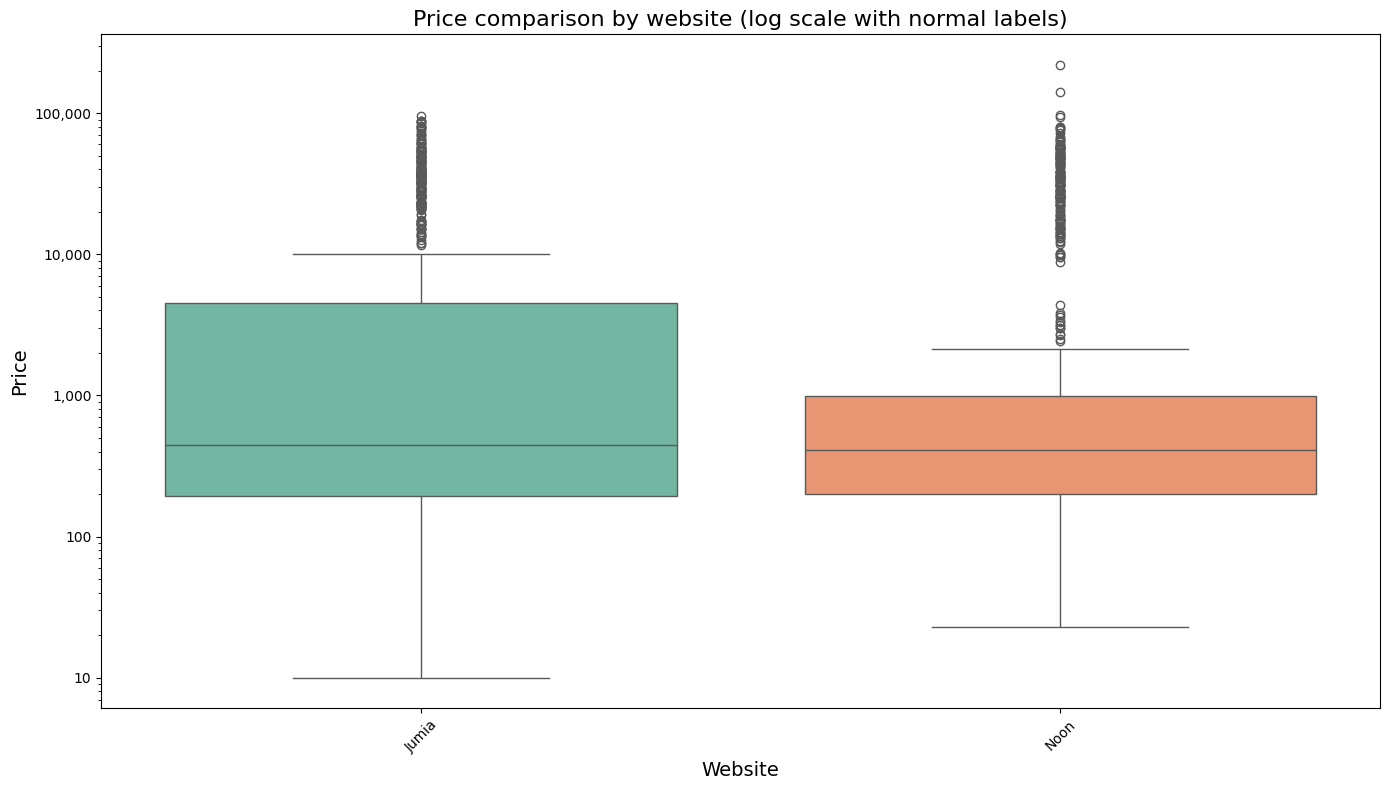

In [27]:

from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(14, 8))

#sns.boxplot(data=df, x="website", y="Price", palette="Set2")

sns.boxplot(data=df, x="website", y="Price", hue="website", palette="Set2", legend=False)
plt.yscale("log") 

formatter = FuncFormatter(lambda y, _: f'{int(y):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Price comparison by website (log scale with normal labels)", fontsize=16)
plt.xlabel("Website", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


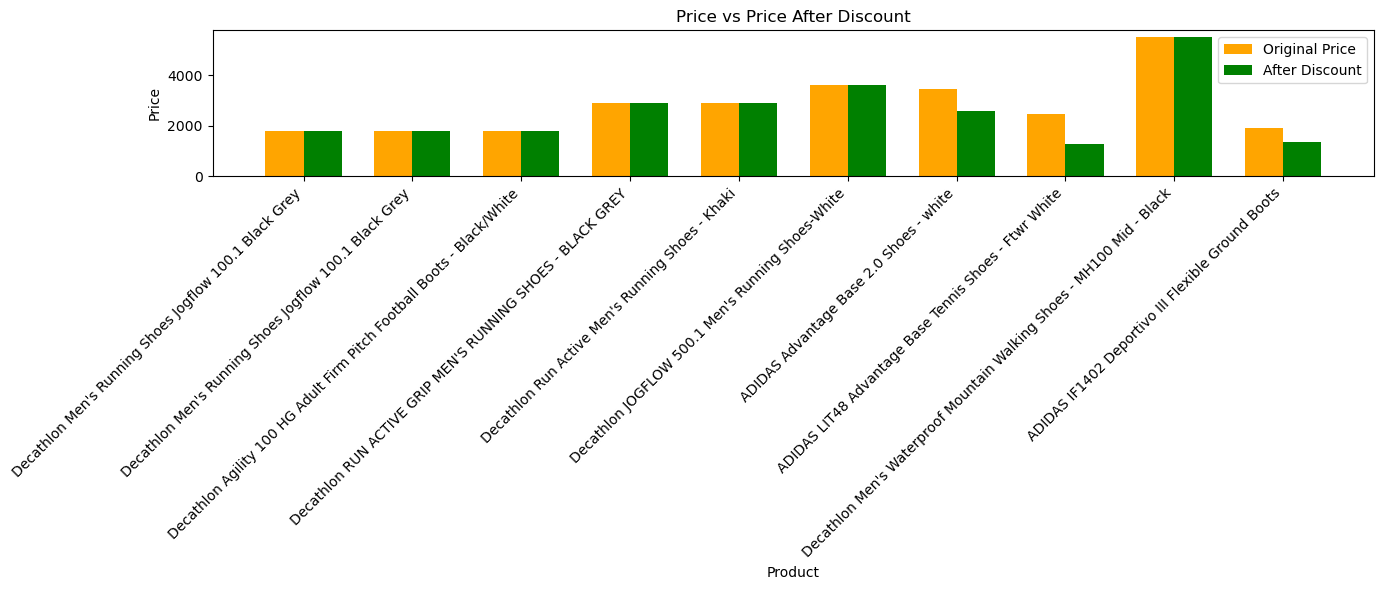

In [ ]:

plt.figure(figsize=(14, 6))

x = np.arange(len(df_sample["Product Name"]))

width = 0.35

plt.bar(x - width/2, df_sample["Price"], width, label="Original Price", color="orange")
plt.bar(x + width/2, df_sample["Price_After_Discount"], width, label="After Discount", color="green")

plt.xticks(x, df_sample["Product Name"], rotation=45, ha='right')
plt.xlabel("Product")
plt.ylabel("Price")
plt.title("Price vs Price After Discount")
plt.legend()
plt.tight_layout()


plt.show()


Text(0.5, 1.0, 'Average Price Before and After Discount')

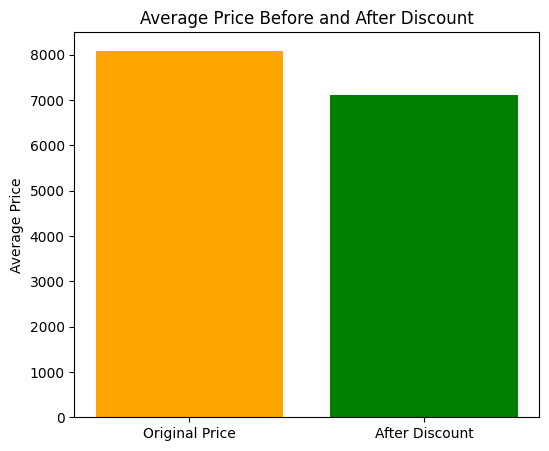

In [28]:
avg_price_before = df["Price"].mean()
avg_price_after = df["Price_After_Discount"].mean()

labels = ["Original Price", "After Discount"]
values = [avg_price_before, avg_price_after]
colors = ["orange", "green"]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Average Price")
plt.title("Average Price Before and After Discount")


In [29]:
pip install plotly.express

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached plotly_express-0.4.1-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached plotly_express-0.4.1-py2.py3-none-any.whl (2.9 kB)
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.8 MB 2.4 MB/s eta 0:00:06
   -- ------------------------------------- 1.0/14.8 MB 2.4 MB/s eta 0:00:06
   ---- ----------------------------------- 1.6/14.8 MB 2.4 MB/s eta 0:00:06
   ----- ---------------------------------- 2.1/14.8 MB 2.3 MB/s eta 0:00:06
   ------- -------------------------------- 2.6/14.8 MB 2.4 MB/s eta 0:00:06
   -------- ------------------------------- 3.1/14.8 MB 2.3 MB/s eta 0:00:05
   --------- ------------------------------ 3.7/14.8 MB 2.3 MB/s eta 0:00:05
   ----------- ---------------------------- 4.2/14.8 MB 2.3 MB/s eta 0:00:05
   ------------ --------------------------- 4.7/14.8 MB 2.3 MB/s eta 0:00:05
   ------------- -----------

In [45]:
import plotly.express as px

top_brands = df['Brand'].value_counts().head(10).index
top_brands_df = df[df['Brand'].isin(top_brands)]
brand_rating_avg = top_brands_df.groupby('Brand')['Rating'].mean().reset_index()

fig1 = px.histogram(df, x='Department', title='Number of Products by Department', color='Department')

fig2 = px.histogram(df, x='website', title='Number of Products by Website', color='website')

fig3 = px.bar(brand_rating_avg, x='Brand', y='Rating', title='Average Rating of Top 10 Brands')

fig4 = px.histogram(df, x='Price', nbins=30, title='Price Distribution')

fig5 = px.scatter(df, x='Price', y='Rating', color='website',
                  title='Price vs Rating', hover_data=['Product Name'])

fig6 = px.box(df, x='website', y='Price', color='website', title='Price Distribution by Website')

top_discount = df.sort_values(by='Discount', ascending=False).head(10)
fig7 = px.bar(top_discount, x='Product Name', y='Discount', color='website',
              title='Top 10 Products by Discount')
fig7.update_layout(xaxis_tickangle=-45)

fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()
fig6.show()
fig7.show()


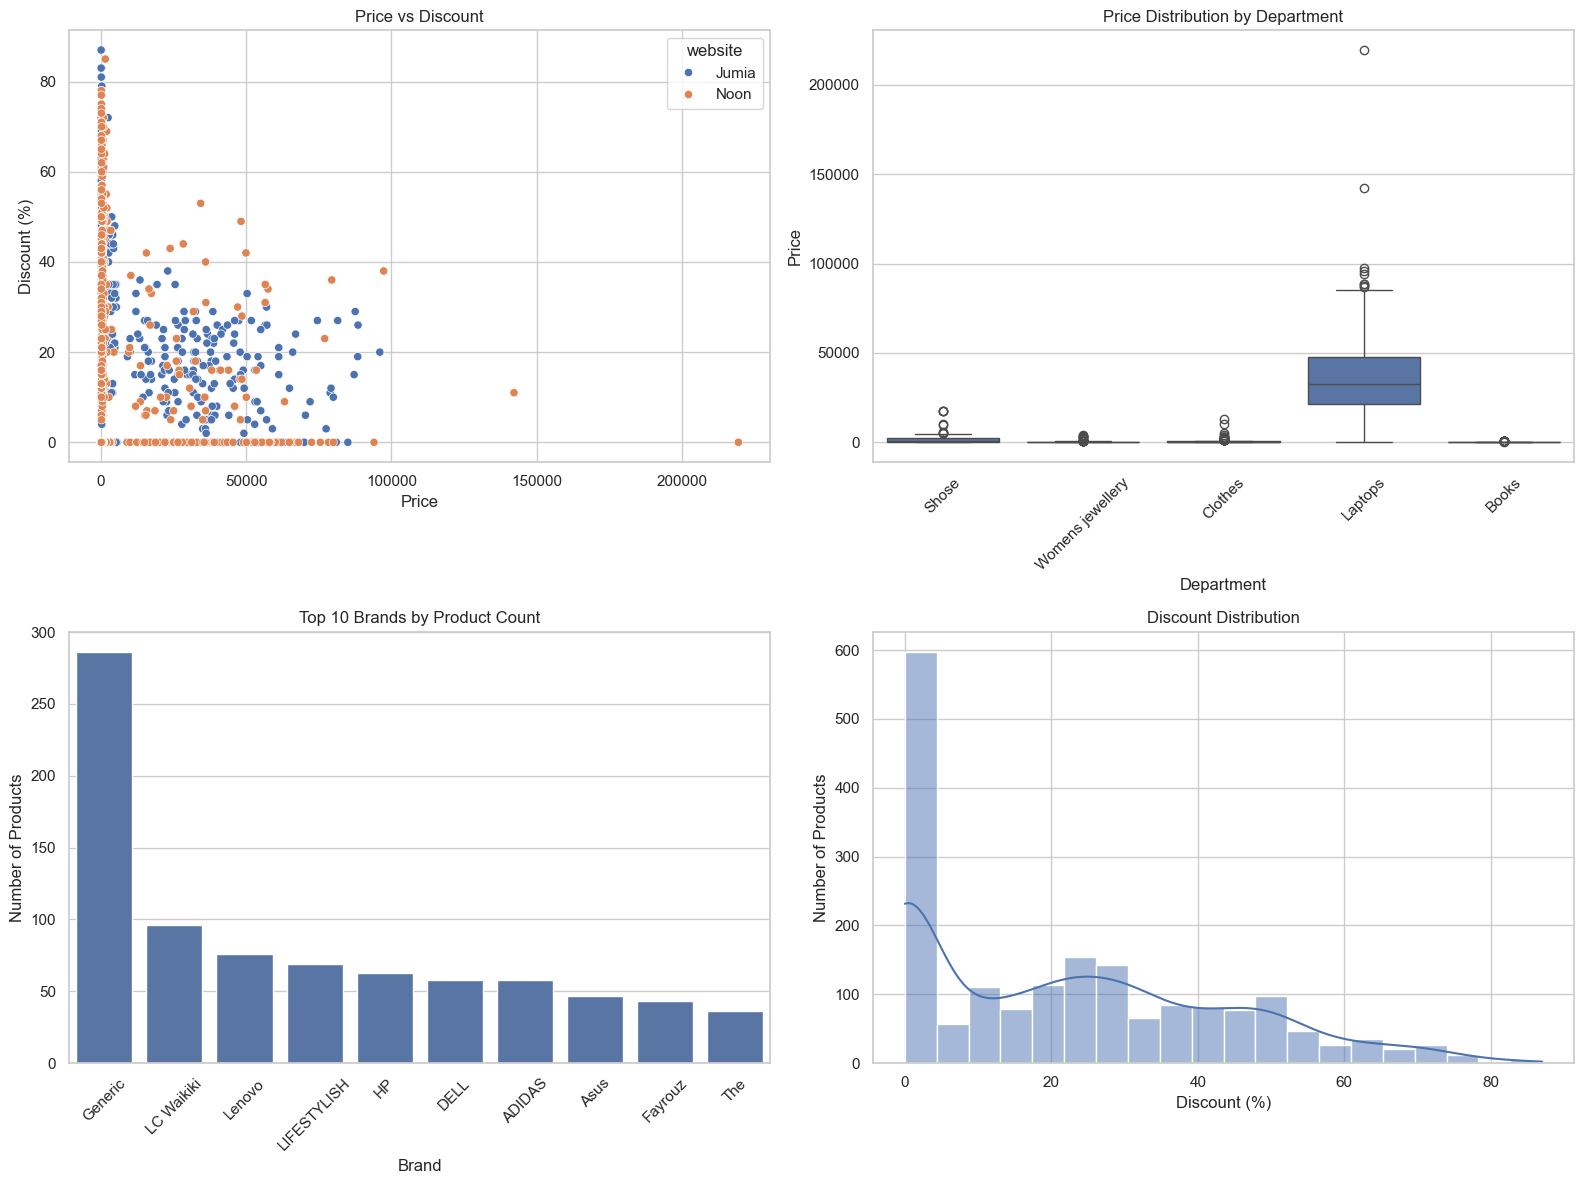

In [ ]:

sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

sns.scatterplot(data=df, x='Price', y='Discount', hue='website', ax=axs[0, 0])
axs[0, 0].set_title("Price vs Discount")
axs[0, 0].set_xlabel("Price")
axs[0, 0].set_ylabel("Discount (%)")

sns.boxplot(data=df, x='Department', y='Price', ax=axs[0, 1])
axs[0, 1].set_title("Price Distribution by Department")
axs[0, 1].set_xlabel("Department")
axs[0, 1].set_ylabel("Price")
axs[0, 1].tick_params(axis='x', rotation=45)

top_10_brands = df['Brand'].value_counts().head(10)
sns.barplot(x=top_10_brands.index, y=top_10_brands.values, ax=axs[1, 0])
axs[1, 0].set_title("Top 10 Brands by Product Count")
axs[1, 0].set_xlabel("Brand")
axs[1, 0].set_ylabel("Number of Products")
axs[1, 0].tick_params(axis='x', rotation=45)

sns.histplot(df['Discount'].dropna(), bins=20, kde=True, ax=axs[1, 1])
axs[1, 1].set_title("Discount Distribution")
axs[1, 1].set_xlabel("Discount (%)")
axs[1, 1].set_ylabel("Number of Products")

plt.tight_layout()
plt.show()


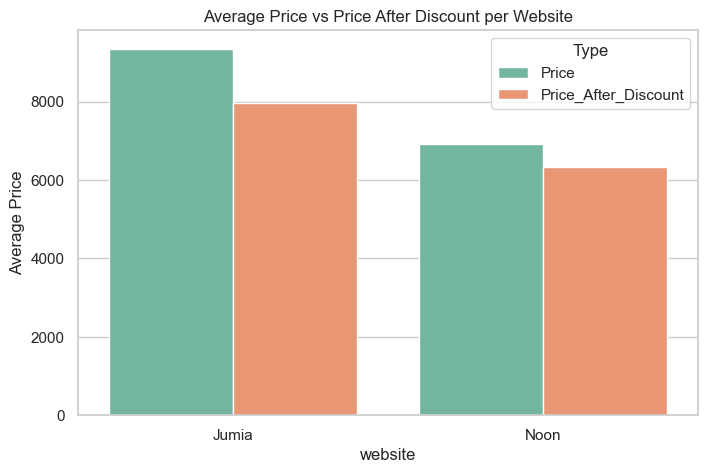

In [ ]:

avg_prices = df.groupby("website")[["Price", "Price_After_Discount"]].mean().reset_index()

plt.figure(figsize=(8,5))
avg_prices_melted = avg_prices.melt(id_vars="website", var_name="Type", value_name="Average Price")

sns.barplot(data=avg_prices_melted, x="website", y="Average Price", hue="Type", palette="Set2")
plt.title("Average Price vs Price After Discount per Website")
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_3704\79486734.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




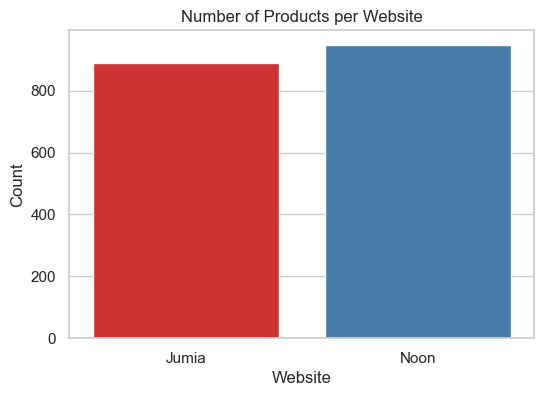

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="website", palette="Set1")
plt.title("Number of Products per Website")
plt.ylabel("Count")
plt.xlabel("Website")
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_3704\2382360318.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




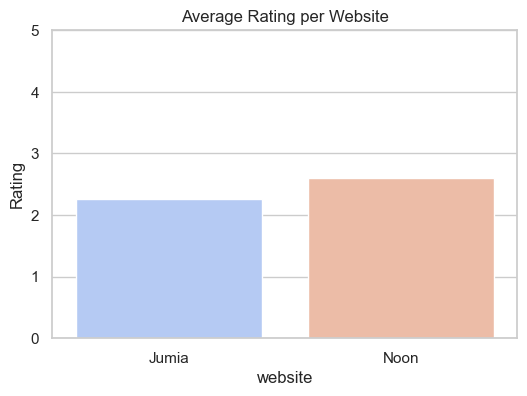

In [50]:
avg_rating = df.groupby("website")["Rating"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_rating, x="website", y="Rating", palette="coolwarm")
plt.title("Average Rating per Website")
plt.ylim(0, 5) 
plt.show()


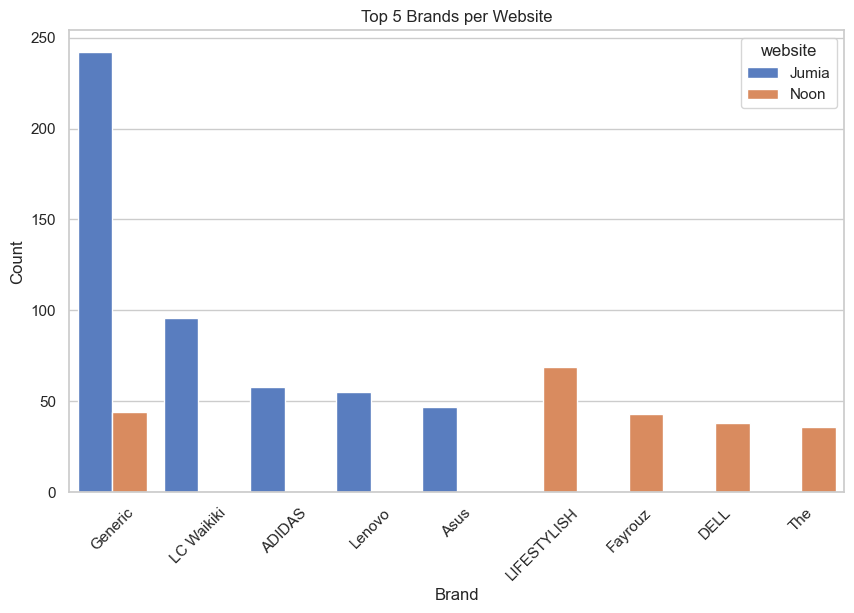

In [52]:
top_brands = df.groupby(["website", "Brand"]).size().reset_index(name="Count")
top_brands = top_brands.sort_values(["website", "Count"], ascending=[True, False])

top5 = top_brands.groupby("website").head(5)

plt.figure(figsize=(10,6))
sns.barplot(data=top5, x="Brand", y="Count", hue="website", palette="muted")
plt.title("Top 5 Brands per Website")
plt.xticks(rotation=45)
plt.show()


In [53]:
pip install pymongo


Note: you may need to restart the kernel to use updated packages.


In [54]:
from pymongo import MongoClient


In [55]:
client = MongoClient("mongodb://localhost:27017/")


In [56]:
db = client["products_db"]       
collection = db["products"]       


In [57]:
data_dict = df.to_dict("records")


In [58]:
collection.insert_many(data_dict)
print(" Data has been successfully inserted into MongoDB!")


 Data has been successfully inserted into MongoDB!


# Machine Learning

In [14]:
laptops_df = df[df["Department"] == "Laptops"][["Price_After_Discount", "Rating", "Discount", "Brand","website"]]
print(laptops_df.shape)
print(laptops_df["Brand"].unique())
laptops_df = laptops_df[laptops_df["Brand"].isin(["Dell", "HP", "Lenovo", "Acer", "Asus"])]
print(laptops_df.head(10))
laptops_df.shape

(392, 5)
['Asus' 'HP' 'Acer' 'Lenovo' 'Generic' 'MSI' 'DELL' 'Apple' 'Microsoft'
 'Gigabyte' 'TAGITOP' 'Fujitsu' 'ASUS' 'JSAUX' 'RAHALA' 'Okade' 'Brand'
 'براند' 'Laptops']
     Price_After_Discount  Rating  Discount   Brand website
553              18591.17     0.0      17.0    Asus   Jumia
554              59999.00     0.0       0.0      HP   Jumia
555              44519.16     1.0      16.0    Asus   Jumia
556              60999.00     0.0       0.0    Asus   Jumia
557               7354.80     4.3      19.0    Asus   Jumia
558              19359.12     0.0      12.0    Acer   Jumia
559               9885.50     3.8      15.0  Lenovo   Jumia
560              25486.23     0.0      23.0      HP   Jumia
561              27891.24     0.0      24.0    Asus   Jumia
562              33949.03     0.0       3.0  Lenovo   Jumia


(203, 5)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

In [16]:
category_features = ["Brand", "website"]
numerical_features = ["Price_After_Discount", "Rating", "Discount"]

preprocessor = ColumnTransformer(transformers=
                                 [
                                    ("cat",OneHotEncoder(),category_features), 
                                    ("num",StandardScaler(), numerical_features),
                                 ])
# تطبيق التحويل على البيانات
transformed_data = preprocessor.fit_transform(laptops_df)
# الحصول على أسماء الأعمدة بعد التحويل
cat_encoder = preprocessor.named_transformers_['cat']
cat_columns = cat_encoder.get_feature_names_out(category_features)

# أسماء الأعمدة النهائية (الفئوية + العددية)
all_columns = list(cat_columns) + numerical_features

DataLap= pd.DataFrame(transformed_data, columns= all_columns)
corr_matrix =DataLap.corr()
print(corr_matrix)

                      Brand_Acer  Brand_Asus  Brand_HP  Brand_Lenovo  \
Brand_Acer              1.000000   -0.165941 -0.202803     -0.233869   
Brand_Asus             -0.165941    1.000000 -0.368208     -0.424611   
Brand_HP               -0.202803   -0.368208  1.000000     -0.518933   
Brand_Lenovo           -0.233869   -0.424611 -0.518933      1.000000   
website_Jumia           0.175118    0.317943 -0.347935     -0.044740   
website_Noon           -0.175118   -0.317943  0.347935      0.044740   
Price_After_Discount   -0.041778   -0.041887  0.112422     -0.047048   
Rating                 -0.091202   -0.128353 -0.021546      0.184666   
Discount                0.119932    0.282529 -0.225819     -0.099021   

                      website_Jumia  website_Noon  Price_After_Discount  \
Brand_Acer                 0.175118     -0.175118             -0.041778   
Brand_Asus                 0.317943     -0.317943             -0.041887   
Brand_HP                  -0.347935      0.347935     

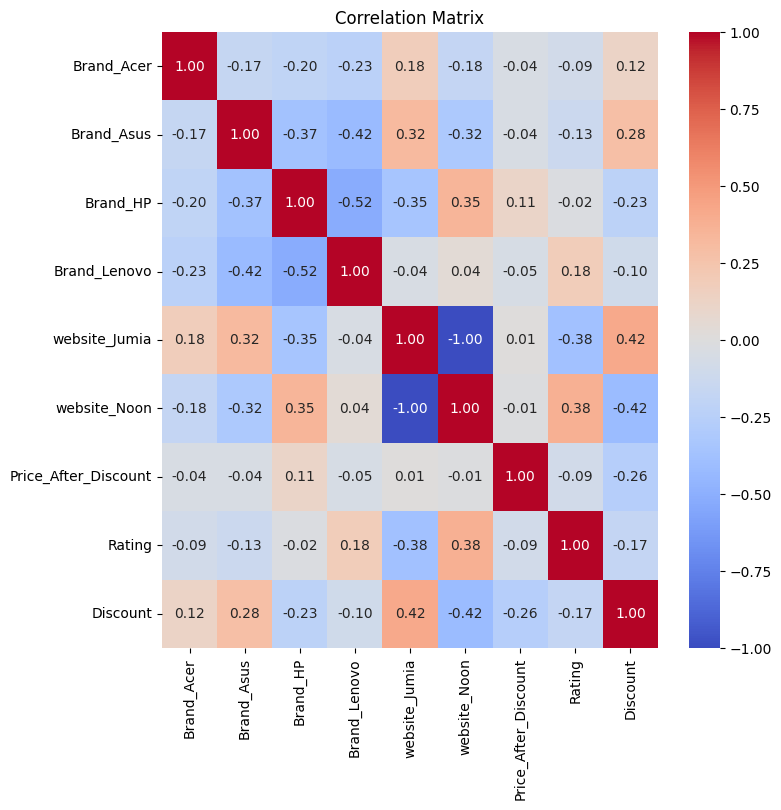

In [17]:
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

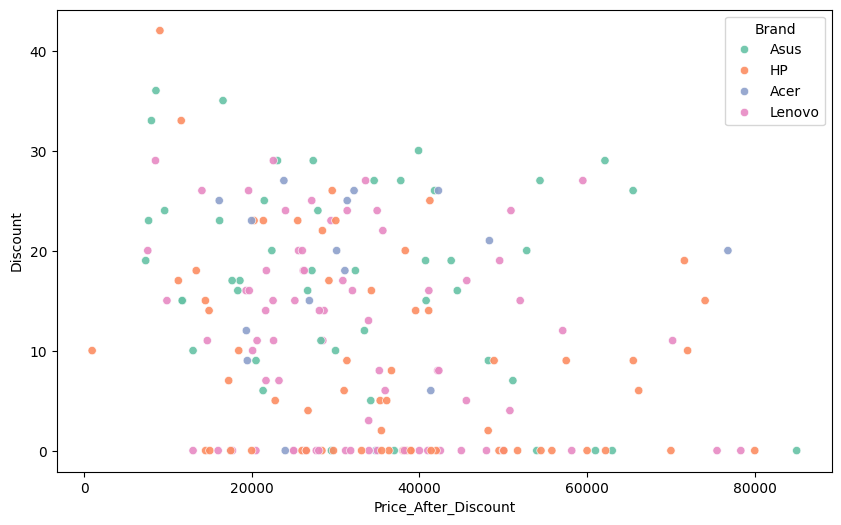

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=laptops_df, x="Price_After_Discount", y="Discount", hue="Brand", palette="Set2",alpha=0.9)
plt.show()

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 453.5 kB/s eta 0:05:30
   ---------------------------------------- 0.8/150.0 MB 799.2 kB/s eta 0:03:07
   ---------------------------------------- 1.0/150.0 MB 915.5 kB/s eta 0:02:43
   ---------------------------------------- 1.0/150.0 MB 915.5 kB/s eta 0:02:43
   ---------------------------------------- 1.0/150.0 MB 915.5 kB/s eta 0:02:43
   ---------------------------------------- 1.0/150.0 MB 915.5 kB/s eta 0:02:43
   ---------------------------------------- 1.0/150.0 MB 915.5 kB/s eta 0:02:43
   ---------------------------------------- 1.6/150.0 MB 671.1 kB/s eta 0:03:42
   ---------------------------------------- 1.6/150.0 MB 671.1 kB/s eta 0:03

In [3]:
from xgboost import XGBRegressor

In [20]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import seaborn as sns
x = DataLap[[ "Rating", "Discount"]]
y = DataLap["Price_After_Discount"]
k=4
kf=KFold(n_splits=k, shuffle=True, random_state=42)
# model=LinearRegression()
model = XGBRegressor(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
scores = cross_val_score(model,x,y,cv=kf,scoring='r2')
print("R2 score: ",scores)
print("Mean R²:", scores.mean())




R2 score:  [-0.08051137 -0.208693    0.03341956 -0.08641044]
Mean R²: -0.08554881116889285



Categorical features: []
Numerical features: ['Rating', 'Discount']
Fold 1: R² = 0.022
Fold 2: R² = 0.148
Fold 3: R² = 0.172
Fold 4: R² = 0.028
Fold 5: R² = -0.080

Final Results:
Mean R²: 0.058 (±0.092)

Top 10 Most Important Features:
Discount    0.285114
Rating      0.139067
dtype: float64


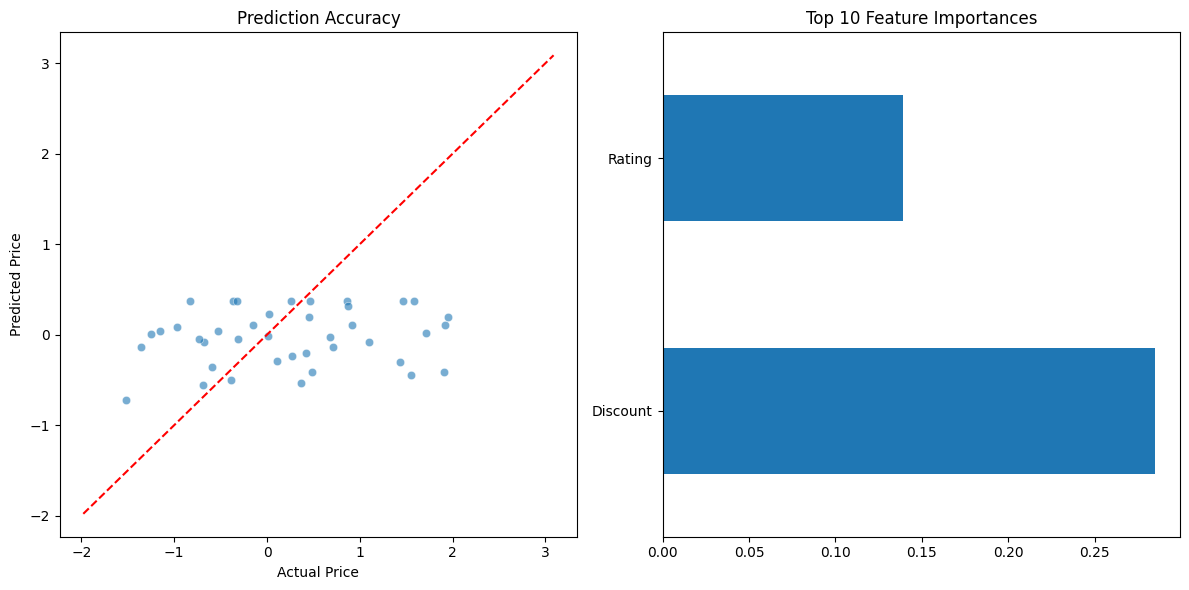


Testing Polynomial Features...
Polynomial R²: 0.057 (±0.083)


In [43]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Data Preparation --------------------------------------------
# Select features and target
X = DataLap[[ "Rating", "Discount"]]
y = DataLap['Price_After_Discount']

# Convert categoricals (auto-detect categorical columns)
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=np.number).columns

print(f"\nCategorical features: {list(cat_cols)}")
print(f"Numerical features: {list(num_cols)}")

# 2. Modeling Pipeline ------------------------------------------
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))  # Regularized regression
])

# 3. Enhanced Cross-Validation ----------------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
feature_importances = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X)):
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # One-hot encode categoricals (per-fold to prevent leakage)
    X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
    X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)
    
    # Align columns (test may have missing categories)
    X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
    
    # Train model
    model_pipeline.fit(X_train_encoded, y_train)
    y_pred = model_pipeline.predict(X_test_encoded)
    
    # Store results
    fold_score = r2_score(y_test, y_pred)
    fold_scores.append(fold_score)
    
    # Get feature importances (absolute coefficient values)
    if fold == 0:  # Only need feature names once
        feature_names = X_train_encoded.columns
    coefs = pd.Series(np.abs(model_pipeline.named_steps['model'].coef_), 
                     index=feature_names)
    feature_importances.append(coefs)
    
    print(f"Fold {fold+1}: R² = {fold_score:.3f}")

# 4. Results Analysis -------------------------------------------
print("\nFinal Results:")
print(f"Mean R²: {np.mean(fold_scores):.3f} (±{np.std(fold_scores):.3f})")

# Feature importance analysis
importance_df = pd.concat(feature_importances, axis=1).mean(axis=1)
print("\nTop 10 Most Important Features:")
print(importance_df.sort_values(ascending=False).head(10))

# 5. Visualization ---------------------------------------------
plt.figure(figsize=(12, 6))

# Actual vs Predicted plot (last fold)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction Accuracy")

# Feature importance plot
plt.subplot(1, 2, 2)
importance_df.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# 6. Optional: Polynomial Features Test ------------------------
# Only proceed if basic model shows R² > 0
if np.mean(fold_scores) > 0:
    print("\nTesting Polynomial Features...")
    from sklearn.preprocessing import PolynomialFeatures
    
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10.0))  # Stronger regularization
    ])
    
    poly_scores = []
    for train_idx, test_idx in kfold.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
        X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)
        X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
        
        poly_pipeline.fit(X_train_encoded, y_train)
        poly_scores.append(r2_score(y_test, poly_pipeline.predict(X_test_encoded)))
    
    print(f"Polynomial R²: {np.mean(poly_scores):.3f} (±{np.std(poly_scores):.3f})")
else:
    print("\nSkipping polynomial features - improve basic model first")